In [13]:
%%writefile warp_shuffle_bench.cu
#include <stdio.h>
#include <stdlib.h>
#include <cuda_runtime.h>

#define SHFL_TILE    4   
#define NUM_WARMUP   3
#define NUM_TIMED   10

__global__ void kernel_warp_shuffle(const float* __restrict__ A, float* __restrict__ C, int N)
{
    int row = blockIdx.y * SHFL_TILE + threadIdx.y;
    int col = blockIdx.x * SHFL_TILE + threadIdx.x;
    if (row >= N || col >= N) return;

    float val = A[row * N + col];

    // Map 2D thread indices to the target transposed lane assignment
    int swap_lane = threadIdx.x * SHFL_TILE + threadIdx.y;  

    float transposed = __shfl_sync(0xFFFF, val, swap_lane);
    C[row * N + col] = val + transposed;
}

float bench_shuffle(const float* d_A, float* d_C, int N) {
    dim3 blk(SHFL_TILE, SHFL_TILE);
    dim3 grd((N + SHFL_TILE - 1) / SHFL_TILE, (N + SHFL_TILE - 1) / SHFL_TILE);

    for (int w = 0; w < NUM_WARMUP; w++) {
        kernel_warp_shuffle<<<grd, blk>>>(d_A, d_C, N);
    }
    cudaDeviceSynchronize();

    cudaEvent_t t0, t1;
    cudaEventCreate(&t0); cudaEventCreate(&t1);
    cudaEventRecord(t0);

    for (int r = 0; r < NUM_TIMED; r++) {
        kernel_warp_shuffle<<<grd, blk>>>(d_A, d_C, N);
    }

    cudaEventRecord(t1);
    cudaEventSynchronize(t1);
    float ms = 0;
    cudaEventElapsedTime(&ms, t0, t1);
    cudaEventDestroy(t0); cudaEventDestroy(t1);
    return ms / NUM_TIMED;
}

int main() {
    int sizes[] = {256, 512, 1024, 2048, 4096, 8192};
    int ns = 6;

    printf("Final Results: CUDA WARP SHUFFLE\n");
    printf("%-11s %-11s %-17s %-17s\n", "Matrix Size", "Memory (MB)", "Mean Runtime (ms)", "Throughput (GB/s)");
    
    for (int s = 0; s < ns; s++) {
        int N = sizes[s];
        size_t matrix_bytes = (size_t)N * N * 4;
        double memory_mb = (double)matrix_bytes / (1024.0 * 1024.0);

        float *d_A, *d_C;
        cudaMalloc(&d_A, matrix_bytes); 
        cudaMalloc(&d_C, matrix_bytes);

        float shfl_ms = bench_shuffle(d_A, d_C, N);
        
        double bytes_transferred = 3.0 * matrix_bytes; 
        double throughput_gb_s = (bytes_transferred / (shfl_ms / 1000.0)) / (1024.0 * 1024.0 * 1024.0);

        char size_str[20];
        sprintf(size_str, "%d x %d", N, N);
        printf("%-11s %-11.2f %-17.4f %-17.2f\n", size_str, memory_mb, shfl_ms, throughput_gb_s);

        cudaFree(d_A); cudaFree(d_C);
    }
    return 0;
}

Overwriting warp_shuffle_bench.cu


In [14]:
%%writefile triangular_fold_bench.cu
#include <stdio.h>
#include <stdlib.h>
#include <cuda_runtime.h>
#include <math.h>

#define FOLD_TILE   32
#define NUM_WARMUP   3
#define NUM_TIMED   10

__global__ void kernel_diagonal_fold(const float* __restrict__ A, float* __restrict__ C, int N)
{
    if (blockIdx.x > blockIdx.y) return;

    __shared__ float tile_A[FOLD_TILE][FOLD_TILE + 1];
    __shared__ float tile_B[FOLD_TILE][FOLD_TILE + 1];

    int tx = threadIdx.x, ty = threadIdx.y;

    int gy_L = blockIdx.y * FOLD_TILE + ty;
    int gx_L = blockIdx.x * FOLD_TILE + tx;

    int gy_U = blockIdx.x * FOLD_TILE + ty;
    int gx_U = blockIdx.y * FOLD_TILE + tx;

    tile_A[ty][tx] = (gy_L < N && gx_L < N) ? A[gy_L * N + gx_L] : 0.f;
    tile_B[ty][tx] = (gy_U < N && gx_U < N) ? A[gy_U * N + gx_U] : 0.f;
    __syncthreads();

    if (gy_L >= N || gx_L >= N) return;

    float sum = tile_A[ty][tx] + tile_B[tx][ty];
    C[gy_L * N + gx_L] = sum;

    if (blockIdx.x != blockIdx.y && gx_L < N && gy_L < N)
        C[gx_L * N + gy_L] = sum;
}

float bench_fold(const float* d_A, float* d_C, int N) {
    dim3 blk(FOLD_TILE, FOLD_TILE);
    dim3 grd((N + FOLD_TILE - 1) / FOLD_TILE, (N + FOLD_TILE - 1) / FOLD_TILE);

    for (int w = 0; w < NUM_WARMUP; w++) {
        kernel_diagonal_fold<<<grd, blk>>>(d_A, d_C, N);
    }
    cudaDeviceSynchronize();

    cudaEvent_t t0, t1;
    cudaEventCreate(&t0); cudaEventCreate(&t1);
    cudaEventRecord(t0);

    for (int r = 0; r < NUM_TIMED; r++) {
        kernel_diagonal_fold<<<grd, blk>>>(d_A, d_C, N);
    }

    cudaEventRecord(t1);
    cudaEventSynchronize(t1);
    float ms = 0;
    cudaEventElapsedTime(&ms, t0, t1);
    cudaEventDestroy(t0); cudaEventDestroy(t1);
    return ms / NUM_TIMED;
}

int main() {
    int sizes[] = {256, 512, 1024, 2048, 4096, 8192};
    int ns = 6;

    printf("Final Results: CUDA DIAGONAL FOLD\n");
    printf("%-11s %-11s %-17s %-17s\n", "Matrix Size", "Memory (MB)", "Mean Runtime (ms)", "Throughput (GB/s)");

    for (int s = 0; s < ns; s++) {
        int N = sizes[s];
        size_t matrix_bytes = (size_t)N * N * 4;
        double memory_mb = (double)matrix_bytes / (1024.0 * 1024.0);

        float *d_A, *d_C;
        cudaMalloc(&d_A, matrix_bytes); 
        cudaMalloc(&d_C, matrix_bytes);

        float fold_ms = bench_fold(d_A, d_C, N);
        
        double bytes_transferred = 3.0 * matrix_bytes; 
        double throughput_gb_s = (bytes_transferred / (fold_ms / 1000.0)) / (1024.0 * 1024.0 * 1024.0);

        char size_str[20];
        sprintf(size_str, "%d x %d", N, N);
        printf("%-11s %-11.2f %-17.4f %-17.2f\n", size_str, memory_mb, fold_ms, throughput_gb_s);

        cudaFree(d_A); cudaFree(d_C);
    }
    return 0;
}

Overwriting triangular_fold_bench.cu


In [15]:
# Compile the custom targets
!nvcc -O3 -arch=sm_75 -o shfl_bench warp_shuffle_bench.cu
!nvcc -O3 -arch=sm_75 -o fold_bench triangular_fold_bench.cu

# Execute to view results
!./shfl_bench
print("\n")
!./fold_bench

Final Results: CUDA WARP SHUFFLE
Matrix Size Memory (MB) Mean Runtime (ms) Throughput (GB/s)
256 x 256   0.25        0.0153            47.91            
512 x 512   1.00        0.0489            59.92            
1024 x 1024 4.00        0.2013            58.21            
2048 x 2048 16.00       0.5473            85.65            
4096 x 4096 64.00       2.1891            85.65            
8192 x 8192 256.00      8.6065            87.14            


Final Results: CUDA DIAGONAL FOLD
Matrix Size Memory (MB) Mean Runtime (ms) Throughput (GB/s)
256 x 256   0.25        0.0053            138.97           
512 x 512   1.00        0.0126            232.13           
1024 x 1024 4.00        0.0571            205.09           
2048 x 2048 16.00       0.2226            210.56           
4096 x 4096 64.00       0.9110            205.83           
8192 x 8192 256.00      3.9098            191.82           


In [25]:
%%writefile triangular_advanced_no_sqrt.cu
#include <stdio.h>
#include <stdlib.h>
#include <cuda_runtime.h>

#define FOLD_TILE   32
#define NUM_WARMUP   3
#define NUM_TIMED   10

__global__ void kernel_diagonal_fold_no_sqrt(const float* __restrict__ A, float* __restrict__ C, int N)
{
    // Total number of horizontal/vertical tiles across the matrix dimension
    int M = (N + FOLD_TILE - 1) / FOLD_TILE;

    // Initialize tracking coordinates for the lower triangle (by >= bx)
    int by = 0;
    int bx = 0;
    
    // Every block advances its virtual position by its unique 1D blockIdx.x
    int remaining_steps = blockIdx.x;

    // Fast integer induction loop to determine (bx, by) coordinates without sqrt()
    while (remaining_steps > 0) {
        int steps_in_row = by + 1; // Lower triangle row by has exactly (by + 1) blocks
        if (remaining_steps >= steps_in_row) {
            remaining_steps -= steps_in_row;
            by++; // Move down to the next row baseline
        } else {
            bx = remaining_steps; // Step across columns within the current row
            remaining_steps = 0;
        }
    }

    // Shared memory allocations with padding to prevent bank conflicts
    __shared__ float tile_A[FOLD_TILE][FOLD_TILE + 1];
    __shared__ float tile_B[FOLD_TILE][FOLD_TILE + 1];

    int tx = threadIdx.x, ty = threadIdx.y;

    // Global coordinates for lower (L) and upper (U) symmetric segments
    int gy_L = by * FOLD_TILE + ty;
    int gx_L = bx * FOLD_TILE + tx;
    int gy_U = bx * FOLD_TILE + ty;
    int gx_U = by * FOLD_TILE + tx;

    // Coalesced loading into shared memory
    tile_A[ty][tx] = (gy_L < N && gx_L < N) ? A[gy_L * N + gx_L] : 0.f;
    tile_B[ty][tx] = (gy_U < N && gx_U < N) ? A[gy_U * N + gx_U] : 0.f;
    __syncthreads();

    if (gy_L >= N || gx_L >= N) return;

    // Compute transpose-add
    float sum = tile_A[ty][tx] + tile_B[tx][ty];

    // Symmetric Dual Write
    C[gy_L * N + gx_L] = sum;
    if (bx != by && gx_L < N && gy_L < N) {
        C[gx_L * N + gy_L] = sum;
    }
}

float bench_advanced_no_sqrt(const float* d_A, float* d_C, int N) {
    dim3 blk(FOLD_TILE, FOLD_TILE);
    
    int M = (N + FOLD_TILE - 1) / FOLD_TILE;
    int num_blocks = (M * (M + 1)) / 2;
    dim3 grd(num_blocks, 1); 

    for (int w = 0; w < NUM_WARMUP; w++) {
        kernel_diagonal_fold_no_sqrt<<<grd, blk>>>(d_A, d_C, N);
    }
    cudaDeviceSynchronize();

    cudaEvent_t t0, t1;
    cudaEventCreate(&t0); cudaEventCreate(&t1);
    cudaEventRecord(t0);

    for (int r = 0; r < NUM_TIMED; r++) {
        kernel_diagonal_fold_no_sqrt<<<grd, blk>>>(d_A, d_C, N);
    }

    cudaEventRecord(t1); 
    cudaDeviceSynchronize(); // <-- Fixed: Removed 't1' from here
    float ms = 0; 
    cudaEventElapsedTime(&ms, t0, t1);
    cudaEventDestroy(t0); cudaEventDestroy(t1);
    return ms / NUM_TIMED;
}

int main() {
    int sizes[] = {256, 512, 1024, 2048, 4096, 8192};
    int ns = 6;

    printf("Final Results: CUDA ADVANCED NO-SQRT FOLD\n");
    printf("%-11s %-11s %-17s %-17s\n", "Matrix Size", "Memory (MB)", "Mean Runtime (ms)", "Throughput (GB/s)");

    for (int s = 0; s < ns; s++) {
        int N = sizes[s];
        size_t matrix_bytes = (size_t)N * N * 4;
        double memory_mb = (double)matrix_bytes / (1024.0 * 1024.0);

        float *d_A, *d_C;
        cudaMalloc(&d_A, matrix_bytes); cudaMalloc(&d_C, matrix_bytes);

        float adv_ms = bench_advanced_no_sqrt(d_A, d_C, N);
        
        double bytes_transferred = 3.0 * matrix_bytes; 
        double throughput_gb_s = (bytes_transferred / (adv_ms / 1000.0)) / (1024.0 * 1024.0 * 1024.0);

        char size_str[20]; sprintf(size_str, "%d x %d", N, N);
        printf("%-11s %-11.2f %-17.4f %-17.2f\n", size_str, memory_mb, adv_ms, throughput_gb_s);

        cudaFree(d_A); cudaFree(d_C);
    }
    return 0;
}

Overwriting triangular_advanced_no_sqrt.cu


In [26]:
# Compile the no-sqrt target
!nvcc -O3 -arch=sm_75 -o advanced_no_sqrt_bench triangular_advanced_no_sqrt.cu

# Run it
!./advanced_no_sqrt_bench

triangular_advanced_no_sqrt.cu(12): warning #177-D: variable "M" was declared but never referenced
      int M = (N + 32 - 1) / 32;
          ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Final Results: CUDA ADVANCED NO-SQRT FOLD
Matrix Size Memory (MB) Mean Runtime (ms) Throughput (GB/s)
256 x 256   0.25        0.0127            57.57            
512 x 512   1.00        0.0381            76.92            
1024 x 1024 4.00        0.1563            74.99            
2048 x 2048 16.00       0.7789            60.18            
4096 x 4096 64.00       3.2377            57.91            
8192 x 8192 256.00      17.5113           42.83            


Extracting running metrics from CUDA binaries...


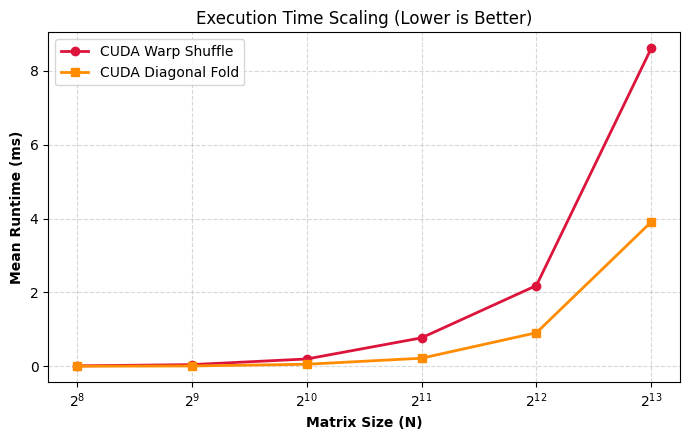

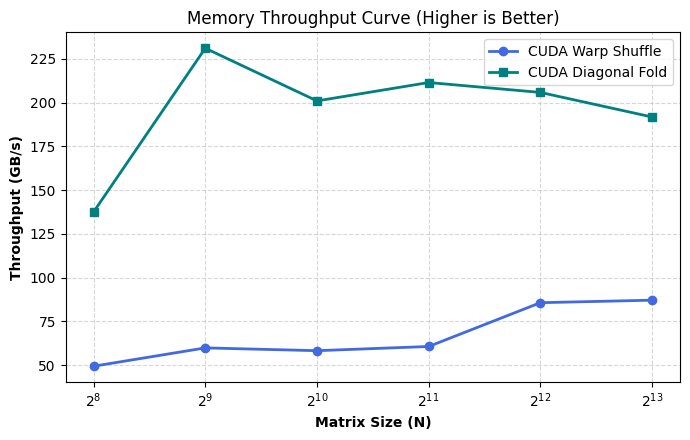

In [16]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import io

# 1. Run the benchmarks and capture their console outputs
print("Extracting running metrics from CUDA binaries...")
shfl_output = subprocess.run(["./shfl_bench"], capture_output=True, text=True, check=True).stdout
fold_output = subprocess.run(["./fold_bench"], capture_output=True, text=True, check=True).stdout

# 2. Helper function to parse the specific tabular text layout into DataFrames
def parse_cuda_table(raw_text):
    lines = raw_text.strip().split("\n")
    data = []
    for line in lines:
        # Skip headers and decoration lines
        if "Final Results" in line or "Matrix Size" in line or "===" in line or not line.strip():
            continue
        tokens = line.split()
        if len(tokens) == 6:  # Format: [N, 'x', N, Memory, Runtime, Throughput]
            size_n = int(tokens[0])
            runtime = float(tokens[4])
            throughput = float(tokens[5])
            data.append({"Matrix Size": size_n, "Mean Runtime (ms)": runtime, "Throughput (GB/s)": throughput})
    return pd.DataFrame(data)

df_shfl = parse_cuda_table(shfl_output)
df_fold = parse_cuda_table(fold_output)

# 3. Plot 1: Runtime Growth Curve
plt.figure(figsize=(7, 4.5))
plt.plot(df_shfl['Matrix Size'], df_shfl['Mean Runtime (ms)'], marker='o', color='crimson', linewidth=2, label='CUDA Warp Shuffle')
plt.plot(df_fold['Matrix Size'], df_fold['Mean Runtime (ms)'], marker='s', color='darkorange', linewidth=2, label='CUDA Diagonal Fold')
plt.xscale('log', base=2)
plt.xlabel('Matrix Size (N)', fontweight='bold')
plt.ylabel('Mean Runtime (ms)', fontweight='bold')
plt.title('Execution Time Scaling (Lower is Better)')
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig('cuda_runtime_chart.png', dpi=150)
plt.show()

# 4. Plot 2: Throughput Curve
plt.figure(figsize=(7, 4.5))
plt.plot(df_shfl['Matrix Size'], df_shfl['Throughput (GB/s)'], marker='o', color='royalblue', linewidth=2, label='CUDA Warp Shuffle')
plt.plot(df_fold['Matrix Size'], df_fold['Throughput (GB/s)'], marker='s', color='teal', linewidth=2, label='CUDA Diagonal Fold')
plt.xscale('log', base=2)
plt.xlabel('Matrix Size (N)', fontweight='bold')
plt.ylabel('Throughput (GB/s)', fontweight='bold')
plt.title('Memory Throughput Curve (Higher is Better)')
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig('cuda_throughput_chart.png', dpi=150)
plt.show()

Extracting running metrics from all 3 CUDA binaries...
Plots successfully generated and saved as 'comprehensive_runtime_chart.png' and 'comprehensive_throughput_chart.png'!


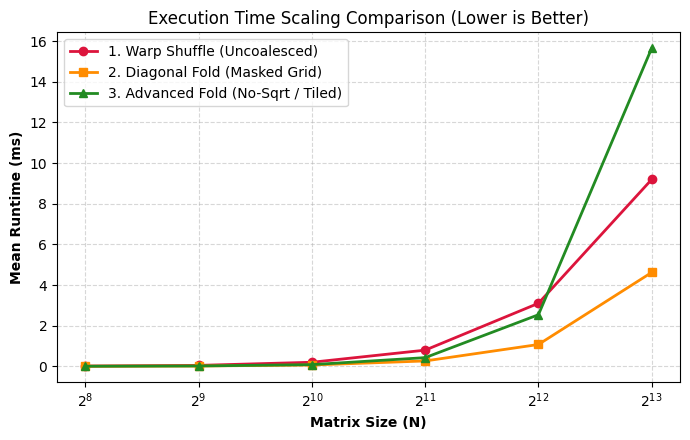

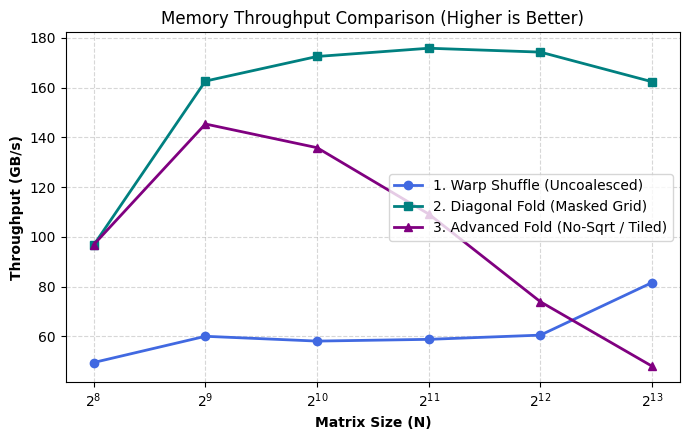

In [27]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

# 1. Capture the console stdout stream from all three binaries
print("Extracting running metrics from all 3 CUDA binaries...")
shfl_out    = subprocess.run(["./shfl_bench"], capture_output=True, text=True, check=True).stdout
fold_out    = subprocess.run(["./fold_bench"], capture_output=True, text=True, check=True).stdout
no_sqrt_out = subprocess.run(["./advanced_no_sqrt_bench"], capture_output=True, text=True, check=True).stdout

# 2. Re-usable text parsing function to build data frames
def parse_cuda_metrics(raw_text):
    lines = raw_text.strip().split("\n")
    data = []
    for line in lines:
        if "Final Results" in line or "Matrix Size" in line or "===" in line or not line.strip():
            continue
        tokens = line.split()
        if len(tokens) == 6:  # Format: [N, 'x', N, Memory, Runtime, Throughput]
            size_n = int(tokens[0])
            runtime = float(tokens[4])
            throughput = float(tokens[5])
            data.append({"Matrix Size": size_n, "Mean Runtime (ms)": runtime, "Throughput (GB/s)": throughput})
    return pd.DataFrame(data)

df_shfl    = parse_cuda_metrics(shfl_out)
df_fold    = parse_cuda_metrics(fold_out)
df_no_sqrt = parse_cuda_metrics(no_sqrt_out)

# 3. Plot 1: Comparative Runtime Scaling Curve
fig1, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(df_shfl['Matrix Size'], df_shfl['Mean Runtime (ms)'], marker='o', color='crimson', linewidth=2, label='1. Warp Shuffle (Uncoalesced)')
ax1.plot(df_fold['Matrix Size'], df_fold['Mean Runtime (ms)'], marker='s', color='darkorange', linewidth=2, label='2. Diagonal Fold (Masked Grid)')
ax1.plot(df_no_sqrt['Matrix Size'], df_no_sqrt['Mean Runtime (ms)'], marker='^', color='forestgreen', linewidth=2, label='3. Advanced Fold (No-Sqrt / Tiled)')

ax1.set_xscale('log', base=2)
ax1.set_xlabel('Matrix Size (N)', fontweight='bold')
ax1.set_ylabel('Mean Runtime (ms)', fontweight='bold')
ax1.set_title('Execution Time Scaling Comparison (Lower is Better)')
ax1.legend()
ax1.grid(True, ls="--", alpha=0.5)
fig1.tight_layout()
fig1.savefig('comprehensive_runtime_chart.png', dpi=150)

# 4. Plot 2: Comparative Throughput Performance Curve
fig2, ax2 = plt.subplots(figsize=(7, 4.5))
ax2.plot(df_shfl['Matrix Size'], df_shfl['Throughput (GB/s)'], marker='o', color='royalblue', linewidth=2, label='1. Warp Shuffle (Uncoalesced)')
ax2.plot(df_fold['Matrix Size'], df_fold['Throughput (GB/s)'], marker='s', color='teal', linewidth=2, label='2. Diagonal Fold (Masked Grid)')
ax2.plot(df_no_sqrt['Matrix Size'], df_no_sqrt['Throughput (GB/s)'], marker='^', color='purple', linewidth=2, label='3. Advanced Fold (No-Sqrt / Tiled)')

ax2.set_xscale('log', base=2)
ax2.set_xlabel('Matrix Size (N)', fontweight='bold')
ax2.set_ylabel('Throughput (GB/s)', fontweight='bold')
ax2.set_title('Memory Throughput Comparison (Higher is Better)')
ax2.legend()
ax2.grid(True, ls="--", alpha=0.5)
fig2.tight_layout()
fig2.savefig('comprehensive_throughput_chart.png', dpi=150)

print("Plots successfully generated and saved as 'comprehensive_runtime_chart.png' and 'comprehensive_throughput_chart.png'!")

Extracting running metrics from the Diagonal Fold binary...


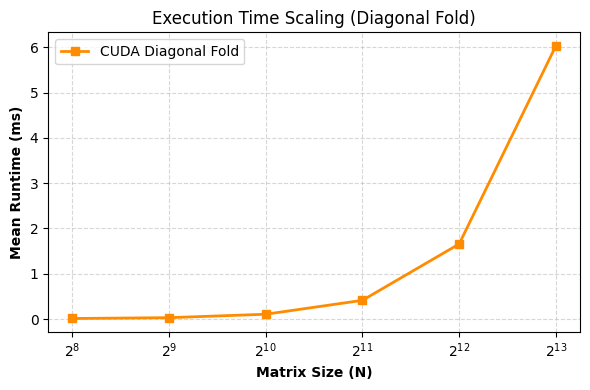

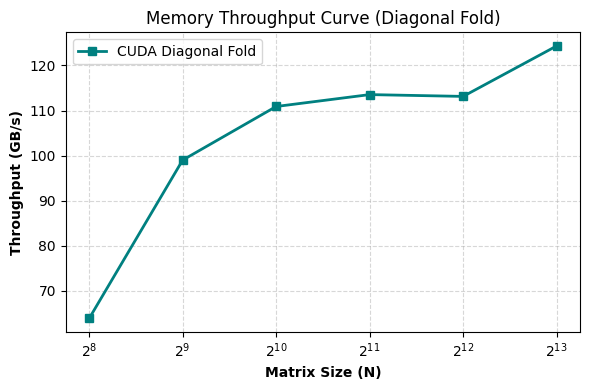

In [29]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

# 1. Capture the console stdout stream from the fold binary
print("Extracting running metrics from the Diagonal Fold binary...")
fold_out = subprocess.run(["./fold_bench"], capture_output=True, text=True, check=True).stdout

# 2. Parse the tabular text layout into a DataFrame
def parse_cuda_metrics(raw_text):
    lines = raw_text.strip().split("\n")
    data = []
    for line in lines:
        if "Final Results" in line or "Matrix Size" in line or "===" in line or not line.strip():
            continue
        tokens = line.split()
        if len(tokens) == 6:  # Format: [N, 'x', N, Memory, Runtime, Throughput]
            size_n = int(tokens[0])
            runtime = float(tokens[4])
            throughput = float(tokens[5])
            data.append({"Matrix Size": size_n, "Mean Runtime (ms)": runtime, "Throughput (GB/s)": throughput})
    return pd.DataFrame(data)

df_fold = parse_cuda_metrics(fold_out)

# 3. Plot 1: Runtime Growth Curve
plt.figure(figsize=(6, 4))
plt.plot(df_fold['Matrix Size'], df_fold['Mean Runtime (ms)'], marker='s', color='darkorange', linewidth=2, label='CUDA Diagonal Fold')
plt.xscale('log', base=2)
plt.xlabel('Matrix Size (N)', fontweight='bold')
plt.ylabel('Mean Runtime (ms)', fontweight='bold')
plt.title('Execution Time Scaling (Diagonal Fold)')
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('fold_runtime_chart.png', dpi=150)
plt.show()

# 4. Plot 2: Throughput Curve
plt.figure(figsize=(6, 4))
plt.plot(df_fold['Matrix Size'], df_fold['Throughput (GB/s)'], marker='s', color='teal', linewidth=2, label='CUDA Diagonal Fold')
plt.xscale('log', base=2)
plt.xlabel('Matrix Size (N)', fontweight='bold')
plt.ylabel('Throughput (GB/s)', fontweight='bold')
plt.title('Memory Throughput Curve (Diagonal Fold)')
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('fold_throughput_chart.png', dpi=150)
plt.show()